# What drives Airbnb prices in Madrid?

Master notebook — runs the full pipeline (imports from `src/`).

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.ingest import download_listings, download_metro_stations
from src.clean import clean_listings
from src.features import engineer_features
from src.model import run_full_pipeline
from src.interpret import run_interpretation
from src.visualize import (
    plot_price_distribution,
    plot_model_comparison,
    plot_feature_importance,
    plot_pdps,
    plot_choropleth,
)

## 2. Ingest

In [2]:
listings_path = download_listings(save_dir="../data/raw/")
metro_path = download_metro_stations(save_dir="../data/raw/")

Listings CSV already present at ../data/raw/listings.csv, skipping download.
Metro stations file already present at ../data/raw/metro_stations.json, skipping download.


## 3. Clean

In [3]:
df_clean = clean_listings(raw_path=listings_path)
print(f"Clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
df_clean.describe().T[["mean", "50%", "std", "min", "max"]]

Loaded raw: 25,000 rows, 79 columns
Column names: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30'

,mean,50%,std,min,max
id,8.256070e+17,9.984127e+17,5.467793e+17,30320.000000,1.508659e+18
latitude,4.042257e+01,4.042072e+01,2.341881e-02,40.331400,4.053553e+01
longitude,-3.694142e+00,-3.700947e+00,2.725752e-02,-3.832060,-3.545904e+00
accommodates,3.306595e+00,3.000000e+00,1.956634e+00,1.000000,1.600000e+01
bedrooms,1.379148e+00,1.000000e+00,9.292641e-01,0.000000,2.500000e+01
minimum_nights,8.338882e+00,2.000000e+00,1.974068e+01,1.000000,6.000000e+02
availability_365,2.134943e+02,2.460000e+02,1.155267e+02,0.000000,3.650000e+02
number_of_reviews,5.989283e+01,1.800000e+01,1.035813e+02,0.000000,1.184000e+03
review_scores_rating,4.650359e+00,4.750000e+00,4.432870e-01,1.000000,5.000000e+00
review_scores_accuracy,4.701371e+00,4.800000e+00,4.119234e-01,1.000000,5.000000e+00


## 4. Feature engineering

In [4]:
df_feat = engineer_features(df_clean, metro_path=metro_path)
print(f"Feature-engineered dataset: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} columns")

Computed distance to nearest metro for 18,924 listings (183 stations).
Top 30 amenities (name: count):
  Wifi: 17539
  Kitchen: 16994
  Hot water: 15039
  Hair dryer: 13783
  Bed linens: 13675
  Dishes and silverware: 13587
  Iron: 13354
  Hangers: 13090
  Microwave: 13006
  Refrigerator: 12767
  TV: 12728
  Essentials: 12277
  Cooking basics: 12072
  Washer: 11854
  Air conditioning: 11308
  Heating: 11064
  Dedicated workspace: 10100
  Shampoo: 9626
  Freezer: 9282
  Coffee maker: 8549
  Toaster: 8492
  Elevator: 8213
  Hot water kettle: 8200
  Room-darkening shades: 7808
  Long term stays allowed: 7566
  Body soap: 7520
  Oven: 7481
  Dining table: 7381
  Dishwasher: 7294
  Drying rack for clothing: 7154
Dropped 0 listings with accommodates > 20
Dropped 3 listings with bedrooms > 10
Final feature count (excluding id/target/geo/raw neighbourhood): 65
Overwriting existing feature file /Users/miguelfa/Projects/airbnb-analysis/data/processed/listings_features.parquet
Saved feature-engin

## 5. EDA (exploratory, not report figures)

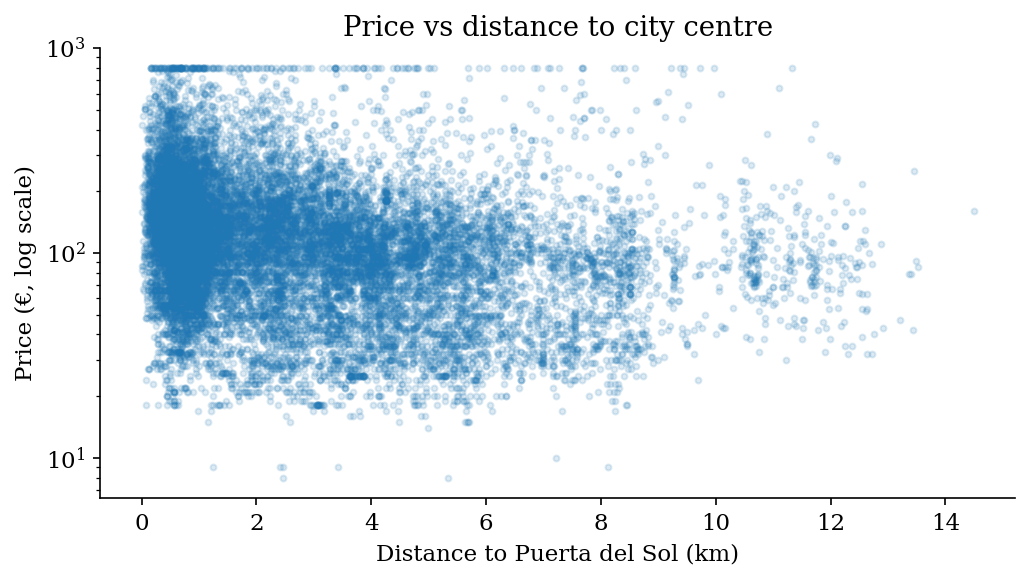

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df_feat["dist_sol_km"], df_feat["price"], alpha=0.15, s=8)
ax.set_yscale("log")
ax.set_xlabel("Distance to Puerta del Sol (km)")
ax.set_ylabel("Price (€, log scale)")
ax.set_title("Price vs distance to city centre")
plt.tight_layout()
plt.show()

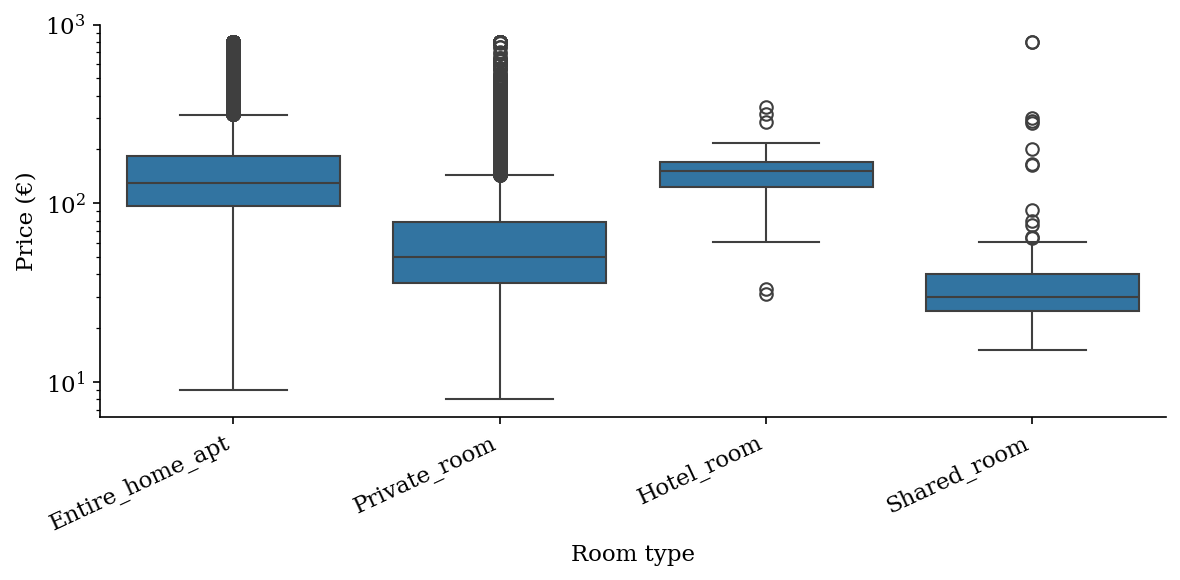

In [6]:
room_cols = [c for c in df_feat.columns if c.startswith("room_type_")]
room_label = df_feat[room_cols].idxmax(axis=1).str.replace("room_type_", "")
tmp = pd.DataFrame({"price": df_feat["price"], "room_type": room_label})
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=tmp, x="room_type", y="price", ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Room type")
ax.set_ylabel("Price (€)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

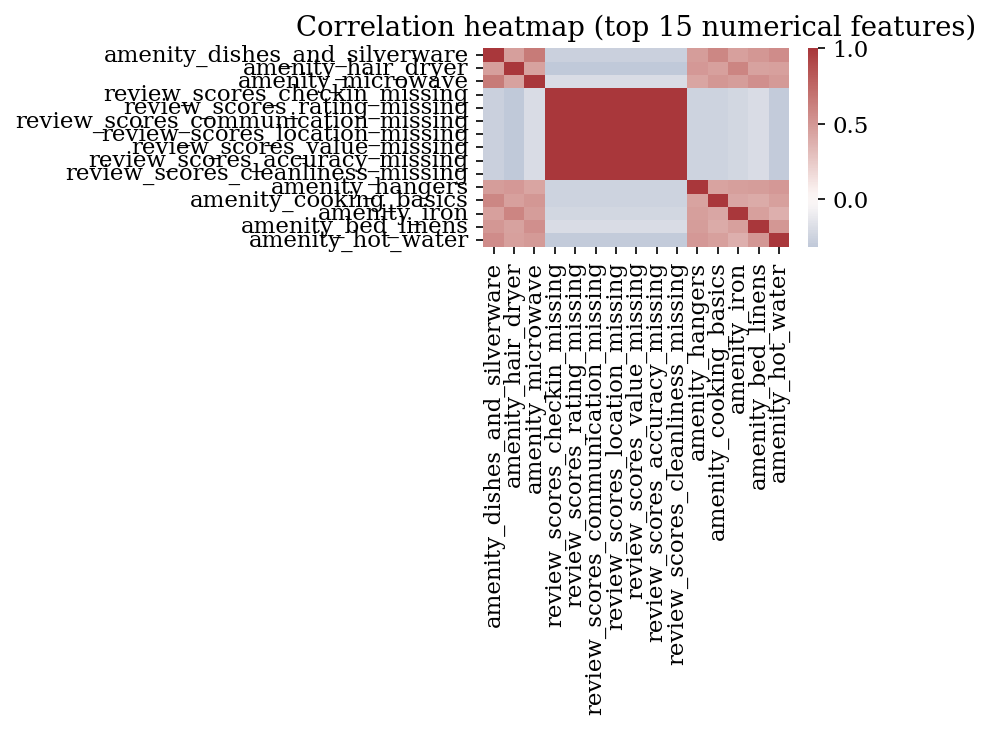

In [7]:
num_candidates = [c for c in df_feat.select_dtypes(include=[np.number]).columns
                  if c not in ("id", "price", "log_price")]
corr = df_feat[num_candidates].corr().abs()
top_cols = corr.mean().sort_values(ascending=False).head(15).index.tolist()
plt.figure(figsize=(6, 5))
sns.heatmap(df_feat[top_cols].corr(), cmap="vlag", center=0)
plt.title("Correlation heatmap (top 15 numerical features)")
plt.tight_layout()
plt.show()

## 6. Modeling

In [8]:
pipeline_results = run_full_pipeline(df_feat)
pipeline_results["results_df"]

Cross-validating OLS (Ridge α=0.01)...
Cross-validating RidgeCV...
Cross-validating LassoCV...
Cross-validating XGBoost (n_estimators=200)...
Fitting final XGBoost (500 trees, early stopping)...
Cross-validating LightGBM (n_estimators=200)...
Fitting final LightGBM (500 trees)...
Model comparison (test R² descending):
                          model  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  test_mae_log  test_mae_eur  test_mape  test_r2
XGBoost (final, early stopping)     0.244461    0.003255    0.754585   0.012289      0.228977     34.565695  23.646791 0.782401
        LightGBM (final, n=500)     0.249242    0.003425    0.746365   0.012261      0.236553     35.880102  24.374416 0.772223
                        RidgeCV     0.312766    0.005498    0.615251   0.018007      0.312110     46.010050  32.521308 0.623452
             OLS (Ridge α=0.01)     0.312784    0.005487    0.615217   0.017987      0.312137     46.012226  32.518138 0.623419
                        LassoCV     0.31

,model,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_mae_log,test_mae_eur,test_mape,test_r2
0,"XGBoost (final, early stopping)",0.244461,0.003255,0.754585,0.012289,0.228977,34.565695,23.646791,0.782401
1,"LightGBM (final, n=500)",0.249242,0.003425,0.746365,0.012261,0.236553,35.880102,24.374416,0.772223
2,RidgeCV,0.312766,0.005498,0.615251,0.018007,0.312110,46.010050,32.521308,0.623452
3,OLS (Ridge α=0.01),0.312784,0.005487,0.615217,0.017987,0.312137,46.012226,32.518138,0.623419
4,LassoCV,0.312822,0.005612,0.614922,0.018383,0.311959,46.010110,32.574645,0.622915


## 7. Interpretation

In [9]:
interp_results = run_interpretation(pipeline_results, df_feat)

Computing permutation feature importance...
Saved /Users/miguelfa/Projects/airbnb-analysis/outputs/feature_importance.csv
Partial dependence for: ['accommodates', 'availability_365', 'minimum_nights', 'dist_sol_km', 'host_listings_count']
Saved /Users/miguelfa/Projects/airbnb-analysis/outputs/district_predictions.csv


## 8. Report figures

In [12]:
plot_price_distribution(df_feat)
plot_model_comparison(pipeline_results["results_df"])
plot_feature_importance(interp_results["imp_df"])
plot_pdps(interp_results["pdp_results"])
plot_choropleth(df_feat, pd.read_csv("../outputs/district_predictions.csv"))

Saved /Users/miguelfa/Projects/airbnb-analysis/outputs/figures/fig1_price_distribution.png
Saved /Users/miguelfa/Projects/airbnb-analysis/outputs/figures/fig2_model_comparison.png
Saved /Users/miguelfa/Projects/airbnb-analysis/outputs/figures/fig3_feature_importance.png
Saved /Users/miguelfa/Projects/airbnb-analysis/outputs/figures/fig4_pdp_plots.png
Saved /Users/miguelfa/Projects/airbnb-analysis/outputs/figures/fig_choropleth.png


PosixPath('/Users/miguelfa/Projects/airbnb-analysis/outputs/figures/fig_choropleth.png')

## 9. Summary statistics for the report

In [11]:
print(f"Total listings after cleaning: N = {len(df_clean):,}")
print(f"After feature engineering: N = {len(df_feat):,}")
p5, p50, p95 = df_feat["price"].quantile([0.05, 0.5, 0.95])
best = pipeline_results["results_df"].iloc[0]
imp3 = interp_results["imp_df"].head(3)["feature"].tolist()
dp = pd.read_csv("../outputs/district_predictions.csv")
hi = dp.loc[dp["median_predicted_price"].idxmax(), "neighbourhood_cleansed"]
lo = dp.loc[dp["median_predicted_price"].idxmin(), "neighbourhood_cleansed"]

print(f"Price range (5th / median / 95th pct): €{p5:.2f} / €{p50:.2f} / €{p95:.2f}")
print(f"Best model: {best['model']}")
print(f"Best test MAE (EUR): €{best['test_mae_eur']:.2f}")
print(f"Best test R² (log price): {best['test_r2']:.4f}")
print(f"Top 3 permutation importance features: {imp3}")
print(f"Highest median predicted price district: {hi}")
print(f"Lowest median predicted price district: {lo}")

Total listings after cleaning: N = 18,924
After feature engineering: N = 18,921
Price range (5th / median / 95th pct): €31.00 / €110.00 / €343.00
Best model: XGBoost (final, early stopping)
Best test MAE (EUR): €34.57
Best test R² (log price): 0.7824
Top 3 permutation importance features: ['room_type_Entire_home_apt', 'accommodates', 'availability_365']
Highest median predicted price district: Recoletos
Lowest median predicted price district: Vinateros
